# 2D Computation Options


In [1]:
from pathlib import Path
from time import perf_counter
import logging
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import (
    HdfMesh,
    HdfPlan,
    HdfResultsMesh,
    HdfResultsPlan,
    RasCmdr,
    RasExamples,
    RasPlan,
    RasUnsteady,
    init_ras_project,
)

logging.disable(logging.CRITICAL)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print(f"ras-commander {ras_commander.__version__}")


ras-commander 0.96.1


## Development Mode

When running this notebook from a source checkout instead of an installed package, start Jupyter from the repository root or add the repository root to `PYTHONPATH` before launching Jupyter. Generated HEC-RAS projects and result HDFs are written under `working/` and are not intended for commit.


# 2D Unsteady Computation Options

This notebook demonstrates the typed 2D unsteady computation options API on a real HEC-RAS 2D example project. It reads the current plan settings, clones a plan into two equation-set scenarios, writes typed 2D settings for equation set, tolerances, initial-condition ramp-up time, and time-step stability controls, runs both plans, and compares computed max water surface elevations.


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
WORK_ROOT = REPO_ROOT / "working" / "2d_computation_options"
PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_SUFFIX = "315_2d_opts"
TEMPLATE_PLAN = "19"
NUM_CORES = 4

RAS_EXE = Path(r"C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe")
ras_exe_arg = str(RAS_EXE) if RAS_EXE.exists() else "7.0"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix=PROJECT_SUFFIX,
)
ras_project = init_ras_project(project_path, ras_exe_arg, load_results_summary=False)

plan_overview_cols = [
    "plan_number",
    "Plan Title",
    "Short Identifier",
    "Program Version",
    "geometry_number",
    "unsteady_number",
    "Computation Interval",
]
plan_overview_cols = [col for col in plan_overview_cols if col in ras_project.plan_df.columns]
display(ras_project.plan_df[plan_overview_cols].sort_values("plan_number").reset_index(drop=True))
print(f"Project folder: {project_path}")
print(f"Template plan: p{TEMPLATE_PLAN}")


,plan_number,Plan Title,Short Identifier,Program Version,geometry_number,unsteady_number,Computation Interval
0,01,SA to Detailed 2D Breach FEQ,SA-2D Det FEQ,5.03,01,01,5SEC
1,02,SA to Detailed 2D Breach,SA-2D Det Brch,5.10,01,01,10SEC
2,03,Single 2D Area - Internal Dam Structure,Single 2D,5.04,09,13,30SEC
3,04,SA to 2D Area Conn - 2D Levee Structure,2D Levee Struc,5.00,13,01,20SEC
4,05,Single 2D area with Bridges FEQ,Single 2D Bridges FEQ,5.10,03,02,5SEC
5,06,Gridded Precip - Infiltration,Grid Precip Infiltration,6.00,09,03,20SEC
6,13,PMF with Multi 2D Areas,PMF Multi 2D,5.10,06,07,30SEC
7,15,1d-2D Dambreak Refined Grid,1D-2D Refined Grid,5.10,08,12,20SEC
8,17,2D to 1D No Dam,2D to 1D No Dam,5.00,10,09,1MIN
9,18,2D to 2D Run,2D to 2D Run,5.00,11,10,20SEC


Project folder: C:\GH\symphony-workspaces\ras-commander\CLB-323\working\2d_computation_options\BaldEagleCrkMulti2D_315_2d_opts
Template plan: p19


## Read Current 2D Settings

`RasPlan.get_2d_flow_options()` reads the plain-text plan settings before any compute. The template plan also points to an unsteady flow file with an explicit storage-area initial condition, which is read through the public `RasUnsteady` wrapper.


In [3]:
template_options = RasPlan.get_2d_flow_options(TEMPLATE_PLAN, ras_object=ras_project)
template_area_rows = pd.DataFrame(template_options["areas"])
template_plan_rows = pd.DataFrame([template_options["plan"]])

template_plan_record = ras_project.plan_df[
    ras_project.plan_df["plan_number"].astype(str).str.zfill(2) == TEMPLATE_PLAN
].iloc[0]
template_unsteady = str(template_plan_record["unsteady_number"]).zfill(2)
template_unsteady_path = project_path / f"{ras_project.project_name}.u{template_unsteady}"
template_ic = RasUnsteady.get_initial_conditions(template_unsteady_path)

display(template_plan_rows)
display(
    template_area_rows[
        [
            "name",
            "equation_set",
            "initial_conditions_time_hours",
            "water_surface_tolerance",
            "volume_tolerance",
            "max_iterations",
            "time_slices",
        ]
    ]
)
display(template_ic)


,computation_interval
0,20SEC


,name,equation_set,initial_conditions_time_hours,water_surface_tolerance,volume_tolerance,max_iterations,time_slices
0,BaldEagleCr,DWE,2.0,0.01,0.01,20,1


,type,river,reach,station,value,area_name
0,storage,None,None,None,630.0,Reservoir Pool


## Clone Plans and Apply Typed Options

The two scenario plans use the same geometry and unsteady flow inputs. The only changes are made through the typed 2D computation-options API.


In [4]:
SCENARIOS = [
    {
        "label": "DWE fixed timestep",
        "shortid": "CLB323_DWE",
        "title": "CLB323 DWE options",
        "options": {
            "equation_set": "DWE",
            "computation_interval": "20SEC",
            "initial_conditions_time_hours": 2.0,
            "water_surface_tolerance": 0.01,
            "volume_tolerance": 0.01,
            "max_iterations": 20,
            "time_step_use_courant": False,
            "time_step_use_time_series": False,
            "time_step_max_courant": None,
            "time_step_min_courant": None,
            "time_step_count_to_double": 0,
            "time_step_max_doubling": 0,
            "time_step_max_halving": 0,
            "time_step_residence_courant": False,
        },
    },
    {
        "label": "SWE-ELM adaptive timestep",
        "shortid": "CLB323_SWE",
        "title": "CLB323 SWE options",
        "options": {
            "equation_set": "SWE-ELM",
            "computation_interval": "20SEC",
            "initial_conditions_time_hours": 2.0,
            "water_surface_tolerance": 0.005,
            "volume_tolerance": 0.005,
            "max_iterations": 30,
            "time_step_use_courant": True,
            "time_step_use_time_series": False,
            "time_step_max_courant": 0.8,
            "time_step_min_courant": 0.35,
            "time_step_count_to_double": 6,
            "time_step_max_doubling": 1,
            "time_step_max_halving": 1,
            "time_step_residence_courant": False,
        },
    },
]


def extract_option_row(plan_number: str, label: str) -> dict:
    opts = RasPlan.get_2d_flow_options(plan_number, ras_object=ras_project)
    area = opts["areas"][0]
    row = {
        "label": label,
        "plan_number": plan_number,
        "program_version": opts["program_version"],
    }
    for key in [
        "computation_interval",
        "time_step_use_courant",
        "time_step_max_courant",
        "time_step_min_courant",
        "time_step_count_to_double",
        "time_step_max_doubling",
        "time_step_max_halving",
    ]:
        row[key] = opts["plan"].get(key)
    for key in [
        "name",
        "equation_set",
        "initial_conditions_time_hours",
        "water_surface_tolerance",
        "volume_tolerance",
        "max_iterations",
    ]:
        row[key] = area.get(key)
    return row


scenario_records = []
for scenario in SCENARIOS:
    plan_number = RasPlan.clone_plan(
        TEMPLATE_PLAN,
        new_plan_shortid=scenario["shortid"],
        new_title=scenario["title"],
        num_cores=NUM_CORES,
        ras_object=ras_project,
    )
    RasPlan.set_2d_flow_options(
        plan_number,
        options=scenario["options"],
        include_default=True,
        ras_object=ras_project,
    )
    scenario_records.append(
        {
            **scenario,
            "plan_number": str(plan_number).zfill(2),
            "hdf_path": project_path / f"{ras_project.project_name}.p{str(plan_number).zfill(2)}.hdf",
        }
    )

plain_text_options = pd.DataFrame(
    [
        extract_option_row(record["plan_number"], record["label"])
        for record in scenario_records
    ]
)
display(plain_text_options)


,label,plan_number,program_version,computation_interval,time_step_use_courant,time_step_max_courant,time_step_min_courant,time_step_count_to_double,time_step_max_doubling,time_step_max_halving,name,equation_set,initial_conditions_time_hours,water_surface_tolerance,volume_tolerance,max_iterations
0,DWE fixed timestep,07,5.00,20SEC,False,NaN,NaN,0,0,0,BaldEagleCr,DWE,2.0,0.010,0.010,20
1,SWE-ELM adaptive timestep,08,5.00,20SEC,True,0.8,0.35,6,1,1,BaldEagleCr,SWE-ELM,2.0,0.005,0.005,30


## Compute Scenario Plans

The plans are run through `RasCmdr.compute_plan()`. No direct `Ras.exe` calls are used.


In [5]:
compute_rows = []
for record in scenario_records:
    start = perf_counter()
    result = RasCmdr.compute_plan(
        record["plan_number"],
        ras_object=ras_project,
        num_cores=NUM_CORES,
        verify=True,
        force_rerun=True,
    )
    elapsed_sec = perf_counter() - start
    success = bool(result)
    hdf_path = record["hdf_path"]
    compute_rows.append(
        {
            "label": record["label"],
            "plan_number": record["plan_number"],
            "success": success,
            "elapsed_sec": elapsed_sec,
            "hdf_exists": hdf_path.exists(),
            "hdf_size_mb": hdf_path.stat().st_size / 1024**2 if hdf_path.exists() else np.nan,
            "hdf_path": hdf_path,
        }
    )
    print(f"{record['label']} p{record['plan_number']}: success={success}, elapsed={elapsed_sec:.1f} sec")
    assert success, f"HEC-RAS compute failed for plan {record['plan_number']}"
    assert hdf_path.exists(), hdf_path

compute_df = pd.DataFrame(compute_rows)
display(compute_df)


DWE fixed timestep p07: success=True, elapsed=42.9 sec


SWE-ELM adaptive timestep p08: success=True, elapsed=95.1 sec


,label,plan_number,success,elapsed_sec,hdf_exists,hdf_size_mb,hdf_path
0,DWE fixed timestep,07,True,42.932393,True,11.096975,C:\GH\symphony-workspaces\ras-commander\CLB-32...
1,SWE-ELM adaptive timestep,08,True,95.116473,True,13.014308,C:\GH\symphony-workspaces\ras-commander\CLB-32...


## Round-Trip HDF Options and Stability Messages

After compute, `HdfPlan.get_2d_flow_options()` confirms the settings that HEC-RAS wrote into each plan HDF. The compute-message summary gives a compact stability/timing comparison using completion flags, warning/error flags, and counts of message lines mentioning Courant, iteration, timestep, or stability terms.


In [6]:
ras_project = init_ras_project(project_path, ras_exe_arg, load_results_summary=True)
results_df = ras_project.results_df.copy()


def message_summary(hdf_path: Path) -> dict:
    text = HdfResultsPlan.get_compute_messages(hdf_path)
    lines = text.splitlines()
    term_pattern = re.compile(r"(courant|iteration|timestep|time step|stability)", re.IGNORECASE)
    warning_pattern = re.compile(r"warning", re.IGNORECASE)
    error_pattern = re.compile(r"error", re.IGNORECASE)
    return {
        "message_chars": len(text),
        "stability_line_count": sum(1 for line in lines if term_pattern.search(line)),
        "warning_line_count": sum(1 for line in lines if warning_pattern.search(line)),
        "error_line_count": sum(1 for line in lines if error_pattern.search(line)),
    }


summary_rows = []
for record in scenario_records:
    hdf_path = record["hdf_path"]
    hdf_opts = HdfPlan.get_2d_flow_options(hdf_path)
    area = hdf_opts["areas"][0]
    plan_result = results_df[
        results_df["plan_number"].astype(str).str.zfill(2) == record["plan_number"]
    ].iloc[0]
    row = {
        "label": record["label"],
        "plan_number": record["plan_number"],
        "hdf_equation_set": area.get("equation_set"),
        "hdf_ic_time_hr": area.get("initial_conditions_time_hours"),
        "hdf_ws_tol": area.get("water_surface_tolerance"),
        "hdf_volume_tol": area.get("volume_tolerance"),
        "hdf_max_iterations": area.get("max_iterations"),
        "completed": bool(plan_result.get("completed")),
        "has_warnings": bool(plan_result.get("has_warnings")),
        "has_errors": bool(plan_result.get("has_errors")),
        "runtime_complete_process_hours": plan_result.get("runtime_complete_process_hours"),
    }
    row.update(message_summary(hdf_path))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).merge(
    compute_df[["plan_number", "elapsed_sec", "hdf_size_mb"]],
    on="plan_number",
    how="left",
)
display(summary_df)

for record in scenario_records:
    text = HdfResultsPlan.get_compute_messages(record["hdf_path"])
    stability_lines = [
        line.strip()
        for line in text.splitlines()
        if re.search(r"(courant|iteration|timestep|time step|stability)", line, re.IGNORECASE)
    ]
    print(f"\n{record['label']} stability-related message sample:")
    for line in stability_lines[:8]:
        print(f"  {line[:180]}")
    if not stability_lines:
        print("  No stability keyword lines found in compute messages.")


,label,plan_number,hdf_equation_set,hdf_ic_time_hr,hdf_ws_tol,hdf_volume_tol,hdf_max_iterations,completed,has_warnings,has_errors,runtime_complete_process_hours,message_chars,stability_line_count,warning_line_count,error_line_count,elapsed_sec,hdf_size_mb
0,DWE fixed timestep,07,DWE,2.0,0.010,0.010,20,True,False,False,0.010239,1809,1,0,2,42.932393,11.096975
1,SWE-ELM adaptive timestep,08,SWE-ELM,2.0,0.005,0.005,30,True,False,False,0.025378,14977,15,0,4,95.116473,13.014308



DWE fixed timestep stability-related message sample:
  Number of warm up time steps:   20

SWE-ELM adaptive timestep stability-related message sample:
  Number of warm up time steps:   20
  Maximum adaptive timestep = 40.0    Minimum adaptive timestep = 10.0
  Initial adaptive timestep = 20.0
  01JAN1999 12:02:00       timestep =            40             (sec)
  Maximum iteration location	Cell	 WSEL	ERROR	ITERATIONS
  01JAN1999 19:18:40       timestep =            20             (sec)
  01JAN1999 22:02:40       timestep =            40             (sec)
  02JAN1999 16:08:00       timestep =            20             (sec)


## Max WSE Comparison

Both scenarios use the same mesh, so max water surface elevations can be joined by mesh name and cell id. The map and histogram show the SWE-ELM max WSE minus the DWE max WSE in feet.


,SWE_minus_DWE_ft
count,4026.000000
mean,0.653483
std,1.011515
min,-1.545166
5%,-0.080307
50%,0.000000
95%,2.065674
max,17.719543


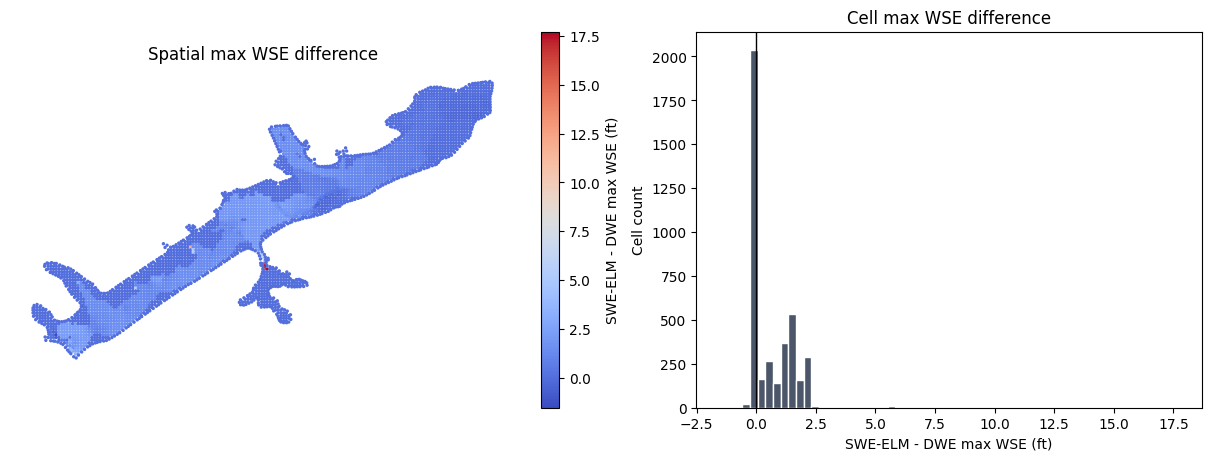

In [7]:
dwe_record = next(record for record in scenario_records if record["label"].startswith("DWE"))
swe_record = next(record for record in scenario_records if record["label"].startswith("SWE"))

dwe_wse = HdfResultsMesh.get_mesh_max_ws(dwe_record["hdf_path"])[
    ["mesh_name", "cell_id", "maximum_water_surface", "geometry"]
].rename(columns={"maximum_water_surface": "dwe_max_wse"})
swe_wse = HdfResultsMesh.get_mesh_max_ws(swe_record["hdf_path"])[
    ["mesh_name", "cell_id", "maximum_water_surface"]
].rename(columns={"maximum_water_surface": "swe_max_wse"})

delta_gdf = dwe_wse.merge(swe_wse, on=["mesh_name", "cell_id"], how="inner")
delta_gdf["delta_wse_ft"] = delta_gdf["swe_max_wse"] - delta_gdf["dwe_max_wse"]
delta_values = delta_gdf["delta_wse_ft"].replace([np.inf, -np.inf], np.nan).dropna()

stats = delta_values.describe(percentiles=[0.05, 0.5, 0.95]).to_frame("SWE_minus_DWE_ft")
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
delta_gdf.plot(
    column="delta_wse_ft",
    ax=axes[0],
    cmap="coolwarm",
    markersize=2,
    legend=True,
    legend_kwds={"label": "SWE-ELM - DWE max WSE (ft)"},
)
axes[0].set_title("Spatial max WSE difference")
axes[0].set_axis_off()

axes[1].hist(delta_values, bins=60, color="#4c566a", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Cell max WSE difference")
axes[1].set_xlabel("SWE-ELM - DWE max WSE (ft)")
axes[1].set_ylabel("Cell count")

plt.show()
